# Development of Strategy to Convert ZIP to FIPS

## DSCI 591 Capstone: Data Center Impact Explorer

* *Jillian Kunze*
* *Andrea MacGregor*
* *Anna Grace*
* *Morgan Murphy*

For a lot of the political datasets, general geographical location is conveyed by FIPS code, but the FracTracker data center dataset has location by (among other things) Zip code. So, I need to develop a strategy to go between these two geographic identifiers. 

RowZero offers a [free dataset](https://rowzero.com/datasets/fips-codes-lookup) with [ZIP code to FIPS code mapping](https://rowzero.com/datasets/fips-codes-lookup#zip-codes-to-fips-codes-mapping); specifically, I will use the page of ZIP codes to FIPS codes. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
zip_fips_df_1 = pd.read_csv("./Data/Copy of FIPS code lists and location mapping - ZIP codes to FIPS codes.csv")
zip_fips_df_1.head()

,ZIP Code,State FIPS code,Primary County FIPS,Metro CBSA,Town,State Abbreviation,State,Primary County,Metro,Total population (5 Year-Estimates)
0,35004,1.0,1115.0,13820.0,Moody,AL,Alabama,St. Clair County,"Birmingham, AL","11,558"
1,35005,1.0,1073.0,13820.0,Adamsville,AL,Alabama,Jefferson County,"Birmingham, AL","8,143"
2,35006,1.0,1073.0,13820.0,Adger,AL,Alabama,Jefferson County,"Birmingham, AL","3,599"
3,35007,1.0,1117.0,13820.0,Alabaster,AL,Alabama,Shelby County,"Birmingham, AL","27,935"
4,35010,1.0,1123.0,10760.0,Alexander City,AL,Alabama,Tallapoosa County,"Alexander City, AL","19,619"


In [6]:
print("Shape:", zip_fips_df_1.shape)
print("Number of ZIP codes:", zip_fips_df_1["ZIP Code"].nunique())
print("Number of county FIPS codes:", zip_fips_df_1["Primary County FIPS"].nunique()) 

Shape: (33772, 10)
Number of ZIP codes: 33772
Number of county FIPS codes: 870


Okay, so this is going to be challenging because this dataset does not include all FIPS code (e.g., during data inspection I found that the MIT precint-level Senate voting data contains 1876 FIPS. The RowZero description says that "Note that this sheet includes the primary county for each ZIP code... (some ZIP codes overlap with multiple counties)."

Happily, the dataset contains a separate page with [Zip to County](https://rowzero.com/datasets/fips-codes-lookup#zip-code-mappings) that I believe should have what I need; and if it doesn't, I can try County to Zip. 

In [2]:
zip_fips_df = pd.read_csv("./Data/Copy of FIPS code lists and location mapping - ZIP to County.csv")
zip_fips_df.head()

,ZIP,County FIPS code,USPS Default State for ZIP,County,County State,State Abbreviation,ZIP Code Population,% of ZIP Residents in County,# of Counties,USPS Default City for ZIP
0,35004,1115,AL,St. Clair County,Alabama,AL,"11,558",100%,1,Moody
1,35005,1073,AL,Jefferson County,Alabama,AL,"8,143",100%,1,Adamsville
2,35006,1073,AL,Jefferson County,Alabama,AL,"3,599",93%,3,Adger
3,35006,1127,AL,Walker County,Alabama,AL,"3,599",5%,3,Adger
4,35006,1125,AL,Tuscaloosa County,Alabama,AL,"3,599",2%,3,Adger


In [5]:
print("Shape:", zip_fips_df.shape)
print("Number of ZIP codes:", zip_fips_df["ZIP"].nunique())
print("Number of county FIPS codes:", zip_fips_df["County FIPS code"].nunique()) 

Shape: (54553, 10)
Number of ZIP codes: 39490
Number of county FIPS codes: 3229


This should hopefully be sufficient.

I'll need to access the % of zip residents in each county when deciding how to assign a ZIP that crosses multiple FIPS. So, I'll first quickly process that so its a number, not an object. 

In [8]:
zip_fips_df["% of ZIP Residents in County"].dtype

dtype('O')

In [11]:
zip_fips_df["Ratio_of_ZIP_Res_in_County"] = zip_fips_df["% of ZIP Residents in County"].str.replace("%", "", regex = True)
zip_fips_df["Ratio_of_ZIP_Res_in_County"] = pd.to_numeric(zip_fips_df["Ratio_of_ZIP_Res_in_County"]) / 100

zip_fips_df[["Ratio_of_ZIP_Res_in_County"]].head(10)

,Ratio_of_ZIP_Res_in_County
0,1.00
1,1.00
2,0.93
3,0.05
4,0.02
5,1.00
6,0.84
7,0.11
8,0.05
9,1.00


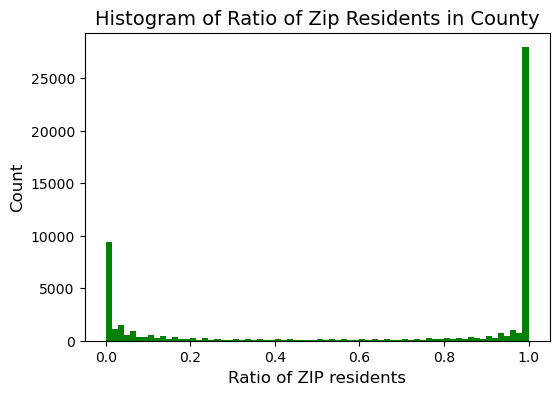

In [10]:
# Check how the ratio of ZIPs is distributed with a histogram 

plt.figure(figsize = (6,4))
zip_fips_df["Ratio_of_ZIP_Res_in_County"].hist(bins = 70, grid = False, color = "green")
plt.title("Histogram of Ratio of Zip Residents in County", fontsize = 14)
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Ratio of ZIP residents", fontsize = 12)
plt.show()

Given this distribution, I feel good about just using whichever FIPS code encompasses the greater ratio of county residents. 

### Find FIPS for Each Data Center 

Next, I'll try to find the FIPS code that correspond to the zip codes for each data center in the Frac Tracker data. 

In [3]:
data_center_df = pd.read_excel("./Data/FracTrackers_Data_Centers_Database.xlsx")
data_center_df.head(5)

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
0,Global Stack Data Center,NaN,NaN,NaN,NaN,Napa,38.585007,-122.58886,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/dev...,https://calistoga.civicweb.net/document/116181...,NaN,NaN,NaN,NaN,NaN,NaN,06/29/2026,06/29/2026
1,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,NaN,North Slope,69.900710,-148.81477,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/sta...,https://www.cbc.ca/news/canada/north/yukon-ala...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,06/24/2026
2,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Operating,Medium,...,https://www.fn-digital.com/data-center,https://www.datacenterdynamics.com/en/news/sta...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,05/20/2026
3,Grant County Data Center,"Just outside the city limits of Sheridan, Arka...",Sheridan,AK,72150.0,Grant,34.306500,-92.40450,Proposed,Low,...,https://www.deltaplexnews.com/local-news/data-...,https://www.southarkansasreckoning.com/grant-c...,https://www.kark.com/news/local-news/people-pr...,https://arktimes.com/arkansas-blog/2025/11/12/...,https://www.kark.com/news/state-news/grant-cou...,NaN,NaN,NaN,04/28/2026,04/28/2026
4,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,Proposed,High,...,https://www.datacenterdynamics.com/en/news/700...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.wbrc.com/2025/11/19/bessemer-city-...,https://www.datacenterdynamics.com/en/news/ala...,https://abc3340.com/news/abc-3340-news-iteam/b...,https://insideclimatenews.org/news/13112025/pr...,09/16/2025,03/13/2026


In [17]:
data_center_df["zip"].head()

0        NaN
1        NaN
2    99734.0
3    72150.0
4    35022.0
Name: zip, dtype: float64

In [20]:
# Nulls vs not nulls for zip code in FracTracker data 
print("Null in data center ZIPs:", data_center_df["zip"].isnull().sum())
print("Not null in data center ZIPs:", data_center_df["zip"].notnull().sum())

Null in data center ZIPs: 52
Not null in data center ZIPs: 1541


It's good to see that the majority of the data centers have ZIP codes listed!

Next, let me choose a test ZIP code to try converting to a ZIP code. 

In [21]:
test_zip = 72150
test_zip_df = zip_fips_df[zip_fips_df["ZIP"] == test_zip]
test_zip_df

,ZIP,County FIPS code,USPS Default State for ZIP,County,County State,State Abbreviation,ZIP Code Population,% of ZIP Residents in County,# of Counties,USPS Default City for ZIP,Ratio_of_ZIP_Res_in_County
2344,72150,5053,AR,Grant County,Arkansas,AR,"12,476",99%,2,Sheridan,0.99
2345,72150,5069,AR,Jefferson County,Arkansas,AR,"12,476",1%,2,Sheridan,0.01


In [22]:
# Find row index correspond to FIPS code with highest proportion of residents in the ZIP code in question 
id_max_pop = test_zip_df["Ratio_of_ZIP_Res_in_County"].idxmax()
# referenced Stack Overflow https://stackoverflow.com/questions/10202570/find-row-where-values-for-column-is-maximal-in-a-pandas-dataframe
id_max_pop 

np.int64(2344)

When a zip crosses two FIPS codes, I'll use the one with the higher % of ZIP residents in that FIPS county. 

In [23]:
# Find FIPS code corresponding to ZIP code in question 
FIPS_for_test_ZIP = test_zip_df.at[id_max_pop, "County FIPS code"]
FIPS_for_test_ZIP

np.int64(5053)

Nice, that seems to work!

In cases where data centers don't have ZIP codes listed or where there is an issue matching the ZIP code, I want to see if I can match them based on county and state name - I'm not doing that as a default because it seems more likely to go wrong. 

In [7]:
# for first try, use a county already formatted the proper way 
test_county = "Grant County, AR" # using this from test above, since I know FIPS code should be 5053
zip_fips_df["County_and_state"] = zip_fips_df["County"] + ", " + zip_fips_df["State Abbreviation"]

zip_fips_df[zip_fips_df["County_and_state"] == test_county]["County FIPS code"].unique()[0]

np.int64(5053)

That seems to work fine when the test county is already formatted properly. But, next I need to wrangle the data centers data to have state and county formatted properly, which might be a bit difficult. 

In [99]:
data_center_df_states = set(data_center_df["state"].unique())
zip_fips_df_states = set(zip_fips_df["State Abbreviation"].unique())

data_center_df_states.difference(zip_fips_df_states)

{'OH ', 'VA '}

In [8]:
# Now, test this with how its formatted in the data center dataset 

test_county_2 = data_center_df.iloc[10]["county"].strip() + " County, " + data_center_df.iloc[10]["state"].strip()
# using strip bc I saw above that a couple of state abbreviations have extra space
print(test_county_2)

zip_fips_df[zip_fips_df["County_and_state"] == test_county_2]["County FIPS code"].unique()[0]

Madison County, AL


np.int64(1089)

Okay, this seems like it will be workable.

Next, I need to turn this whole process into a function to be able to use it with the whole dataset.

In [9]:
def ZIP_to_FIPS_with_county(input_zip, input_county = None, input_state = None): 
    '''
    Input a zip code, county, and state; output the corresponding FIPS code
    Uses RowZero Zip to County dataset
    If ZIP code corresponds to multiple FIPS code, uses the one with highest proportion of residents 
    '''
    # First, if no zip code is available or it is not represented in the ZIP to FIPS dataset, 
    # try to find the FIPS code based on the county and state name
    if math.isnan(input_zip) or input_zip not in zip_fips_df["ZIP"].unique():
        if (not input_county) or (not input_state): 
            return None
        input_county_state = input_county.strip() + " County, " + str(input_state).strip()
        FIPS_for_input = zip_fips_df[zip_fips_df["County_and_state"] == input_county_state]["County FIPS code"].unique() 
        if len(FIPS_for_input) > 0: 
            return FIPS_for_input[0] # there should always be only one entry in this list, since each county has one FIPS code
        else: 
            return None

    # If ZIP code is available, use it to find FIPS code
    input_zip_df = zip_fips_df[zip_fips_df["ZIP"] == int(input_zip)]
    id_max_pop = input_zip_df["Ratio_of_ZIP_Res_in_County"].idxmax()
    FIPS_for_input_ZIP = input_zip_df.at[id_max_pop, "County FIPS code"]
    return FIPS_for_input_ZIP

In [12]:
# Testing
print("For zip code 99734, FIPS code is", ZIP_to_FIPS_with_county(99734))
print("For zip code 72150, FIPS code is", ZIP_to_FIPS_with_county(72150))
print("For zip code 35022, FIPS code is", ZIP_to_FIPS_with_county(35022))
print("For zip code 21702, FIPS code is", ZIP_to_FIPS_with_county(21702))
print("For zip code 19130, FIPS code is", ZIP_to_FIPS_with_county(19130))

For zip code 99734, FIPS code is 2185
For zip code 72150, FIPS code is 5053
For zip code 35022, FIPS code is 1073
For zip code 21702, FIPS code is 24021
For zip code 19130, FIPS code is 42101


I checked these values manually against the Row Zero spreadsheet, and all seems correct!

It's also worth noting that some FIPS codes begin with 0s, so when I'm joining datasets later I may need to account for that. 

Since this function seems to be working, I can try using it with all the ZIP codes in the FracTracker dataset

In [12]:
# Referenced Stack Overflow on using apply with multiple columns: 
# https://stackoverflow.com/questions/13331698/how-to-apply-a-function-to-two-columns-of-pandas-dataframe
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html

test_fips_data_centers = data_center_df.apply(lambda x: ZIP_to_FIPS_with_county(x["zip"], x["county"], x["state"]), axis = 1)
test_fips_data_centers

0           NaN
1           NaN
2        2185.0
3        5053.0
4        1073.0
         ...   
1588    56021.0
1589    56021.0
1590    56021.0
1591    56021.0
1592    56041.0
Length: 1593, dtype: float64

In [143]:
test_fips_data_centers.value_counts()

51107.0    190
51153.0     68
13121.0     59
51059.0     29
48029.0     26
          ... 
54053.0      1
54059.0      1
54069.0      1
26099.0      1
51121.0      1
Name: count, Length: 535, dtype: int64

The FIPS that appears most is for [Loudoun County](https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt), Virginia, which is known to be a big area for data centers, so this seems like a reasonable result!

In [144]:
print("Null in data center ZIPs:", data_center_df["zip"].isnull().sum())
print("Null in data center FIPS:", test_fips_data_centers.isnull().sum())

Null in data center ZIPs: 52
Null in data center FIPS: 5


This results in very few null values for the data center FIPS, which is great! And there's fewer null FIPS than there are null ZIPs, which means that the method for finding FIPS based on county and state when ZIP is not available seems to be working. 

Finally, I can actually add the FIPS code as a column to the dataset.

In [13]:
data_center_df["fips"] = data_center_df.apply(lambda x: ZIP_to_FIPS_with_county(x["zip"], x["county"], x["state"]), axis = 1)
data_center_df.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated,fips
0,Global Stack Data Center,NaN,NaN,NaN,NaN,Napa,38.585007,-122.58886,Proposed,Medium,...,https://calistoga.civicweb.net/document/116181...,NaN,NaN,NaN,NaN,NaN,NaN,06/29/2026,06/29/2026,NaN
1,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,NaN,North Slope,69.900710,-148.81477,Proposed,Medium,...,https://www.cbc.ca/news/canada/north/yukon-ala...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,06/24/2026,NaN
2,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Operating,Medium,...,https://www.datacenterdynamics.com/en/news/sta...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,05/20/2026,2185.0
3,Grant County Data Center,"Just outside the city limits of Sheridan, Arka...",Sheridan,AK,72150.0,Grant,34.306500,-92.40450,Proposed,Low,...,https://www.southarkansasreckoning.com/grant-c...,https://www.kark.com/news/local-news/people-pr...,https://arktimes.com/arkansas-blog/2025/11/12/...,https://www.kark.com/news/state-news/grant-cou...,NaN,NaN,NaN,04/28/2026,04/28/2026,5053.0
4,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,Proposed,High,...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.wbrc.com/2025/11/19/bessemer-city-...,https://www.datacenterdynamics.com/en/news/ala...,https://abc3340.com/news/abc-3340-news-iteam/b...,https://insideclimatenews.org/news/13112025/pr...,09/16/2025,03/13/2026,1073.0


### Grouping Data Centers by FIPS, and Initial Inspection

To start, I'll just find the number of data centers per FIPS code; but, later on, I'll try to add in additional things like average size and what companies have their data centers there. 

In [14]:
dc_per_fips = (data_center_df.groupby("fips").size().reset_index(name = "data_center_count"))
dc_per_fips.head()

,fips,data_center_count
0,1071.0,1
1,1073.0,3
2,1089.0,2
3,1101.0,1
4,1103.0,1


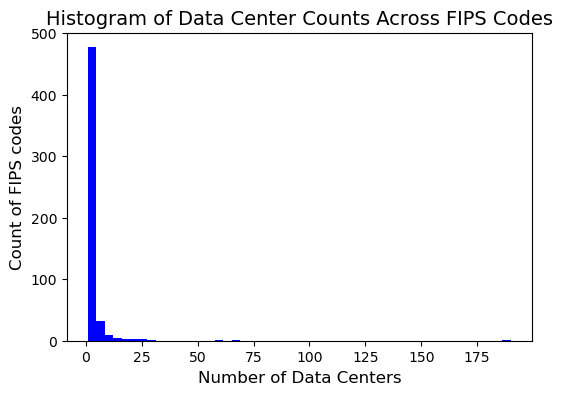

In [15]:
plt.figure(figsize = (6,4))
dc_per_fips["data_center_count"].hist(bins = 50, grid = False, color = "blue")
plt.title("Histogram of Data Center Counts Across FIPS Codes", fontsize = 14)
plt.ylabel("Count of FIPS codes", fontsize = 12)
plt.xlabel("Number of Data Centers", fontsize = 12)
plt.show()

This is a very skewed distribution, with most FIPS codes only having a small number of data centers within them.

I'll continue with this work, and combine this data with other political datasets, in the notebook `Join_data_centers_and_politics.ipynb`